# 深度學習模型比較

比較不同的深度神經網路架構在功夫動作分類任務上的表現：

| 模型 | 描述 |
|------|------|
| Shallow DNN | 2 層隱藏層 (簡單) |
| Medium DNN | 4 層隱藏層 (目前使用) |
| Deep DNN | 6 層隱藏層 (更深) |
| Wide DNN | 更多神經元 |
| ResNet DNN | 帶殘差連接 |
| LeakyReLU DNN | 使用 LeakyReLU 激活函數 |

## 1. 匯入套件

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# 檢查 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")
print(f"PyTorch 版本: {torch.__version__}")

# 設定隨機種子以確保可重現性
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

使用裝置: cuda
PyTorch 版本: 2.9.1+cu128


## 2. 載入與預處理資料

In [3]:
# 讀取資料
csv_path = './dataset/pose_angles_summary_actual.csv'
df = pd.read_csv(csv_path)

print(f"總樣本數: {len(df)}")
print(f"\n各動作類型數量:")
print(df['Action_Type'].value_counts())

# 定義特徵欄位
feature_columns = [
    'R_Elbow_Angle', 'L_Elbow_Angle',
    'R_Knee_Angle', 'L_Knee_Angle',
    'R_Hip_Angle', 'L_Hip_Angle'
]

# 準備特徵和標籤
X = df[feature_columns].values
y = df['Action_Type'].values

# 標籤編碼
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n特徵維度: {X.shape}")
print(f"類別數量: {num_classes}")

總樣本數: 265

各動作類型數量:
Action_Type
act4    74
act1    67
act2    63
act3    61
Name: count, dtype: int64

特徵維度: (265, 6)
類別數量: 4


In [4]:
# 建立 Dataset
class KungfuDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# 建立資料集並分割
full_dataset = KungfuDataset(X_scaled, y_encoded)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# 建立 DataLoader
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"訓練集: {len(train_dataset)} | 驗證集: {len(val_dataset)} | 測試集: {len(test_dataset)}")

訓練集: 185 | 驗證集: 39 | 測試集: 41


## 3. 定義不同的模型架構

In [5]:
# 模型 1: 淺層 DNN (2 層)
class ShallowDNN(nn.Module):
    """2 層隱藏層的簡單網路"""
    def __init__(self, input_size=6, num_classes=4, dropout_rate=0.3):
        super(ShallowDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            
            nn.Linear(16, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)


# 模型 2: 中層 DNN (4 層) - 目前使用的
class MediumDNN(nn.Module):
    """4 層隱藏層 (目前使用的架構)"""
    def __init__(self, input_size=6, num_classes=4, dropout_rate=0.3):
        super(MediumDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)


# 模型 3: 深層 DNN (6 層)
class DeepDNN(nn.Module):
    """6 層隱藏層的深層網路"""
    def __init__(self, input_size=6, num_classes=4, dropout_rate=0.3):
        super(DeepDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)


# 模型 4: 寬層 DNN
class WideDNN(nn.Module):
    """更寬的網路 (更多神經元)"""
    def __init__(self, input_size=6, num_classes=4, dropout_rate=0.3):
        super(WideDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)


# 模型 5: ResNet 風格 DNN (帶殘差連接)
class ResidualBlock(nn.Module):
    """殘差塊"""
    def __init__(self, in_features, out_features, dropout_rate=0.3):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.BatchNorm1d(out_features),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(out_features, out_features),
            nn.BatchNorm1d(out_features)
        )
        
        # 如果維度不同，需要投影
        self.shortcut = nn.Linear(in_features, out_features) if in_features != out_features else nn.Identity()
        self.relu = nn.ReLU()
    
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.block(x)
        out += residual
        return self.relu(out)


class ResNetDNN(nn.Module):
    """帶殘差連接的 DNN"""
    def __init__(self, input_size=6, num_classes=4, dropout_rate=0.3):
        super(ResNetDNN, self).__init__()
        
        self.input_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        
        self.res_block1 = ResidualBlock(64, 128, dropout_rate)
        self.res_block2 = ResidualBlock(128, 64, dropout_rate)
        self.res_block3 = ResidualBlock(64, 32, dropout_rate)
        
        self.output_layer = nn.Linear(32, num_classes)
    
    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        return self.output_layer(x)


# 模型 6: 使用 LeakyReLU 的 DNN
class LeakyReLUDNN(nn.Module):
    """使用 LeakyReLU 激活函數"""
    def __init__(self, input_size=6, num_classes=4, dropout_rate=0.3):
        super(LeakyReLUDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)


print("已定義 6 種模型架構")

已定義 6 種模型架構


## 4. 定義訓練與評估函數

In [6]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """訓練一個 epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(train_loader), correct / total


def validate(model, val_loader, criterion, device):
    """驗證模型"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(val_loader), correct / total


def evaluate_model(model, test_loader, device):
    """在測試集上評估模型"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            outputs = model(features)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return accuracy, f1, np.array(all_preds), np.array(all_labels)


def count_parameters(model):
    """計算模型參數量"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("訓練與評估函數已定義")

訓練與評估函數已定義


In [7]:
def train_model(model, model_name, train_loader, val_loader, device, 
                num_epochs=100, patience=20, learning_rate=0.001):
    """
    完整訓練一個模型
    
    回傳:
        model: 訓練後的模型
        history: 訓練歷史
        training_time: 訓練時間（秒）
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    patience_counter = 0
    best_model_state = None
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            break
    
    training_time = time.time() - start_time
    
    # 載入最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    print(f"  {model_name}: 訓練 {len(history['train_loss'])} epochs, "
          f"最佳驗證準確率: {best_val_acc:.4f}, 耗時: {training_time:.1f}s")
    
    return model, history, training_time


print("模型訓練函數已定義")

模型訓練函數已定義


## 5. 訓練所有模型

In [8]:
# 定義要比較的模型
models_config = {
    'Shallow DNN (2層)': ShallowDNN,
    'Medium DNN (4層)': MediumDNN,
    'Deep DNN (6層)': DeepDNN,
    'Wide DNN': WideDNN,
    'ResNet DNN': ResNetDNN,
    'LeakyReLU DNN': LeakyReLUDNN
}

# 儲存結果
results = {}
trained_models = {}
histories = {}

print("開始訓練所有模型...")
print("=" * 70)

for name, ModelClass in models_config.items():
    # 重新創建資料載入器以確保相同的資料分割
    torch.manual_seed(SEED)
    
    model = ModelClass(input_size=6, num_classes=num_classes)
    params = count_parameters(model)
    
    trained_model, history, train_time = train_model(
        model, name, train_loader, val_loader, device,
        num_epochs=100, patience=20
    )
    
    # 測試集評估
    test_acc, test_f1, preds, labels = evaluate_model(trained_model, test_loader, device)
    
    results[name] = {
        'params': params,
        'train_time': train_time,
        'best_val_acc': max(history['val_acc']),
        'test_acc': test_acc,
        'test_f1': test_f1,
        'epochs': len(history['train_loss']),
        'predictions': preds,
        'labels': labels
    }
    
    trained_models[name] = trained_model
    histories[name] = history

print("=" * 70)
print("所有模型訓練完成！")

開始訓練所有模型...
  Shallow DNN (2層): 訓練 33 epochs, 最佳驗證準確率: 0.9744, 耗時: 1.0s
  Medium DNN (4層): 訓練 23 epochs, 最佳驗證準確率: 0.9744, 耗時: 0.5s
  Deep DNN (6層): 訓練 34 epochs, 最佳驗證準確率: 1.0000, 耗時: 1.0s
  Wide DNN: 訓練 24 epochs, 最佳驗證準確率: 1.0000, 耗時: 0.6s
  ResNet DNN: 訓練 42 epochs, 最佳驗證準確率: 1.0000, 耗時: 1.6s
  LeakyReLU DNN: 訓練 26 epochs, 最佳驗證準確率: 1.0000, 耗時: 0.6s
所有模型訓練完成！


## 6. 結果比較

In [9]:
# 建立結果表格
results_df = pd.DataFrame({
    '模型': list(results.keys()),
    '參數量': [results[k]['params'] for k in results],
    '訓練時間(秒)': [round(results[k]['train_time'], 1) for k in results],
    '訓練輪數': [results[k]['epochs'] for k in results],
    '最佳驗證準確率': [round(results[k]['best_val_acc'] * 100, 2) for k in results],
    '測試準確率(%)': [round(results[k]['test_acc'] * 100, 2) for k in results],
    '測試 F1 分數': [round(results[k]['test_f1'] * 100, 2) for k in results]
})

# 按測試準確率排序
results_df = results_df.sort_values('測試準確率(%)', ascending=False)

print("\n" + "=" * 80)
print("模型比較結果")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)


模型比較結果
              模型    參數量  訓練時間(秒)  訓練輪數  最佳驗證準確率  測試準確率(%)  測試 F1 分數
      ResNet DNN  60644      1.6    42   100.00     97.56     97.53
        Wide DNN 283588      0.6    24   100.00     97.56     97.53
   LeakyReLU DNN  19812      0.6    26   100.00     97.56     97.53
 Medium DNN (4層)  19812      0.5    23    97.44     95.12     95.12
   Deep DNN (6層)  86500      1.0    34   100.00     95.12     95.12
Shallow DNN (2層)    916      1.0    33    97.44     92.68     92.73


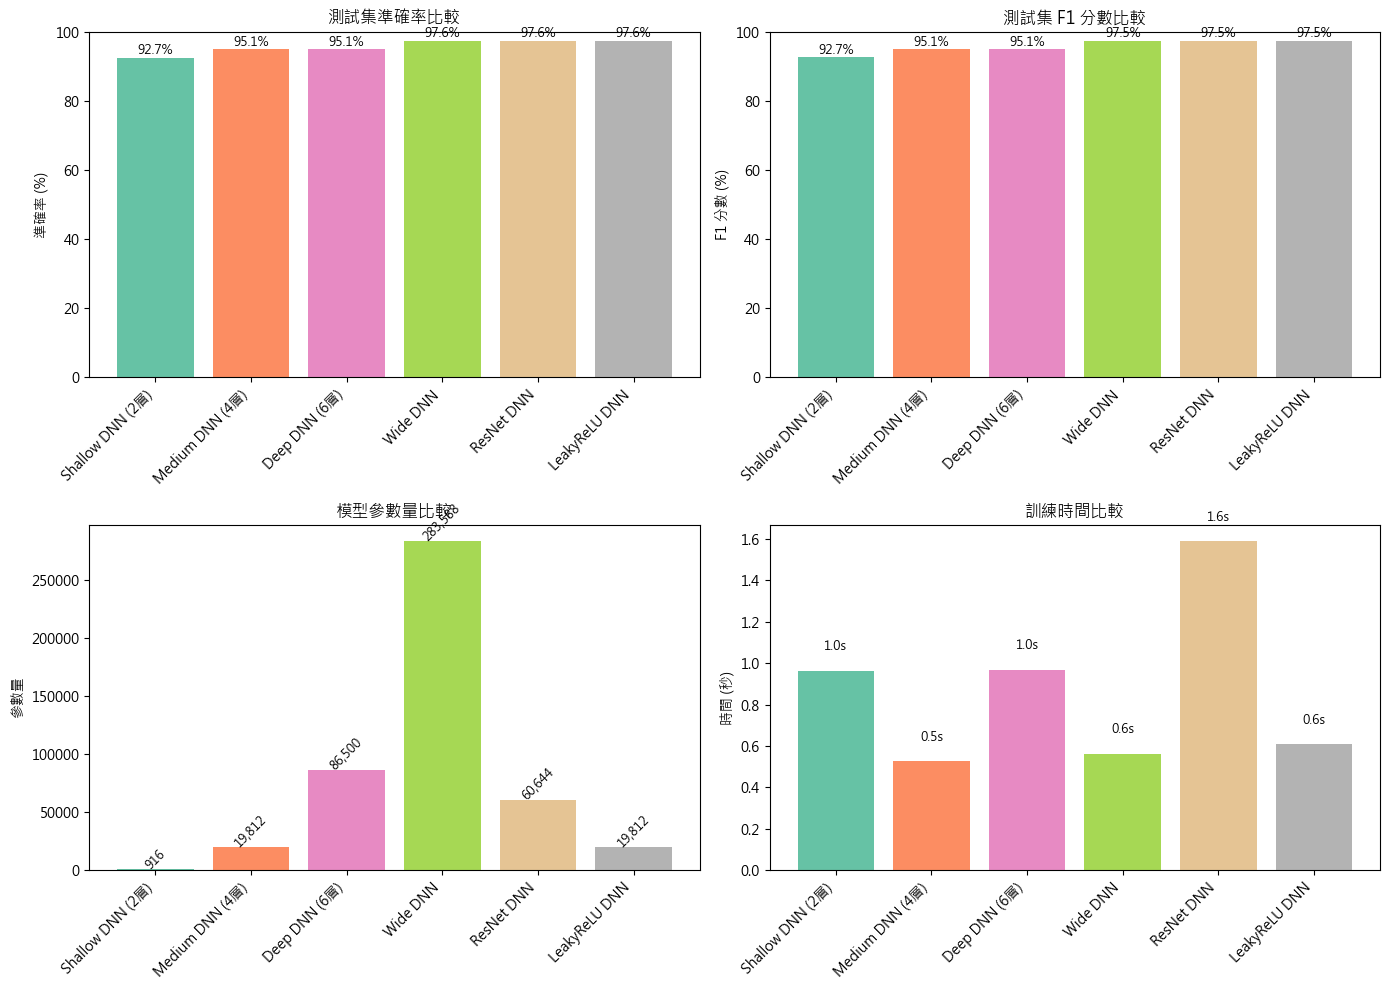


比較圖已儲存至 ./model/model_comparison.png


In [10]:
# 視覺化比較
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_names = list(results.keys())
colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

# 1. 測試準確率比較
ax1 = axes[0, 0]
test_accs = [results[k]['test_acc'] * 100 for k in model_names]
bars1 = ax1.bar(range(len(model_names)), test_accs, color=colors)
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.set_ylabel('準確率 (%)')
ax1.set_title('測試集準確率比較')
ax1.set_ylim(0, 100)
for bar, acc in zip(bars1, test_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}%', ha='center', fontsize=9)

# 2. F1 分數比較
ax2 = axes[0, 1]
f1_scores = [results[k]['test_f1'] * 100 for k in model_names]
bars2 = ax2.bar(range(len(model_names)), f1_scores, color=colors)
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.set_ylabel('F1 分數 (%)')
ax2.set_title('測試集 F1 分數比較')
ax2.set_ylim(0, 100)
for bar, f1 in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{f1:.1f}%', ha='center', fontsize=9)

# 3. 參數量比較
ax3 = axes[1, 0]
params = [results[k]['params'] for k in model_names]
bars3 = ax3.bar(range(len(model_names)), params, color=colors)
ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.set_ylabel('參數量')
ax3.set_title('模型參數量比較')
for bar, p in zip(bars3, params):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{p:,}', ha='center', fontsize=9, rotation=45)

# 4. 訓練時間比較
ax4 = axes[1, 1]
train_times = [results[k]['train_time'] for k in model_names]
bars4 = ax4.bar(range(len(model_names)), train_times, color=colors)
ax4.set_xticks(range(len(model_names)))
ax4.set_xticklabels(model_names, rotation=45, ha='right')
ax4.set_ylabel('時間 (秒)')
ax4.set_title('訓練時間比較')
for bar, t in zip(bars4, train_times):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{t:.1f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('./model/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n比較圖已儲存至 ./model/model_comparison.png")

## 7. 訓練曲線比較

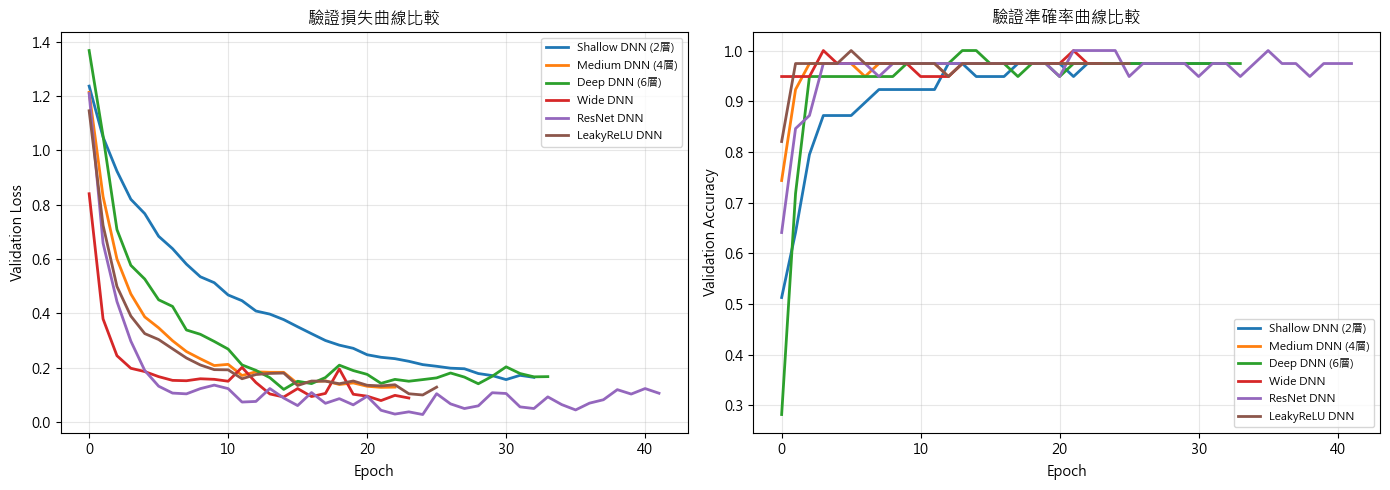

訓練曲線比較圖已儲存至 ./model/training_curves_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 訓練損失曲線
for i, (name, history) in enumerate(histories.items()):
    axes[0].plot(history['val_loss'], label=name, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('驗證損失曲線比較')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# 驗證準確率曲線
for i, (name, history) in enumerate(histories.items()):
    axes[1].plot(history['val_acc'], label=name, linewidth=2)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('驗證準確率曲線比較')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./model/training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("訓練曲線比較圖已儲存至 ./model/training_curves_comparison.png")

## 8. 混淆矩陣比較

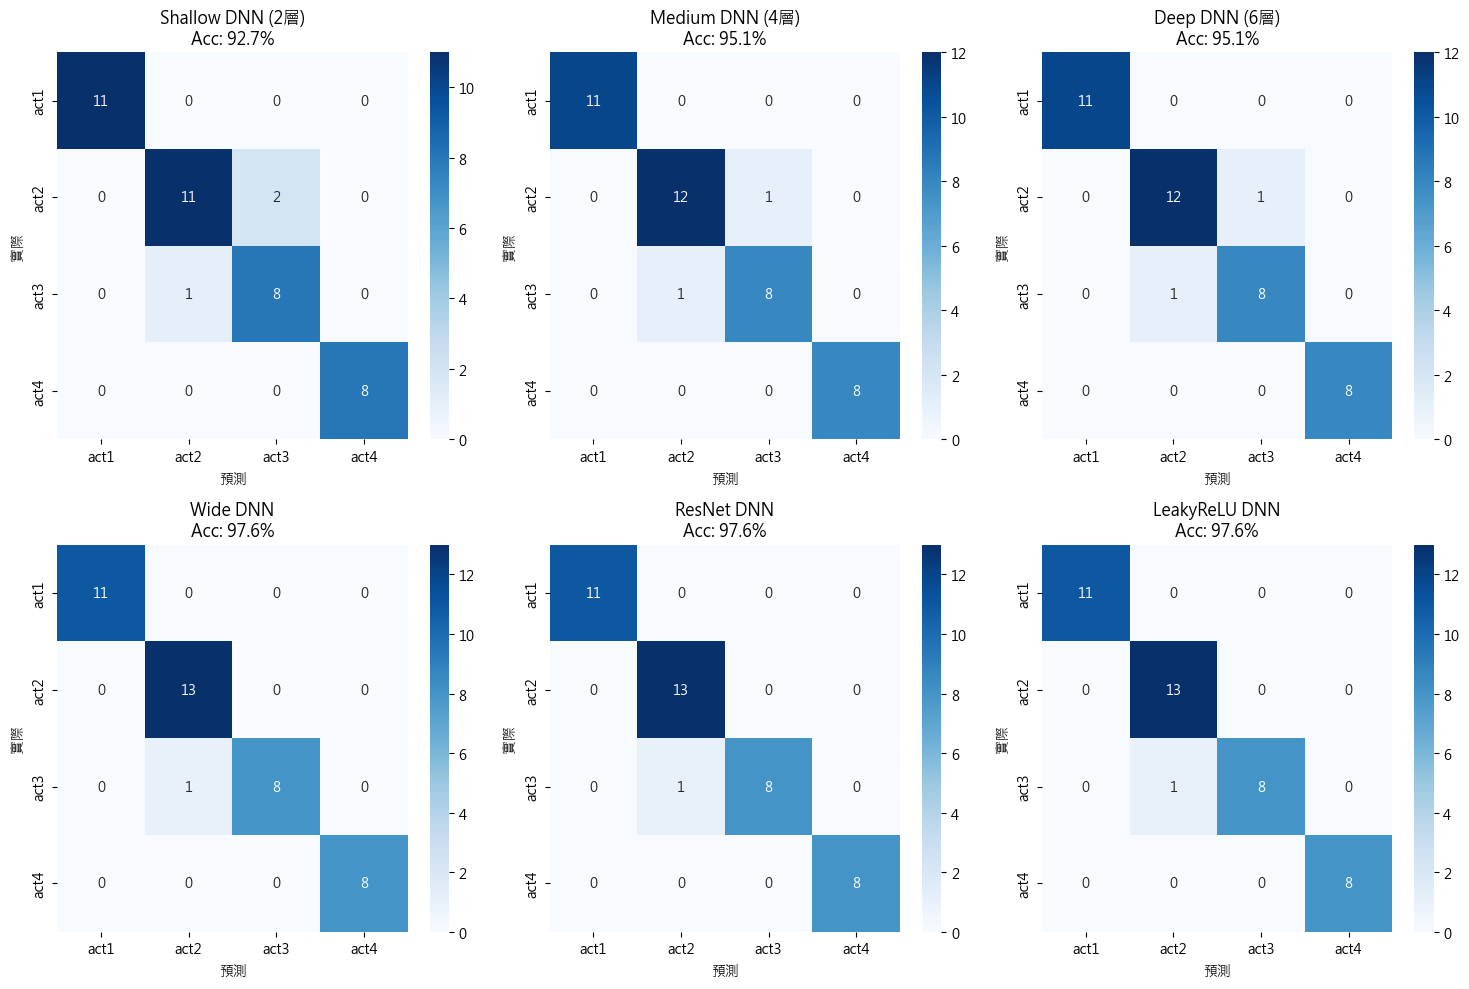

混淆矩陣比較圖已儲存至 ./model/confusion_matrices_comparison.png


In [12]:
# 繪製各模型的混淆矩陣
n_models = len(results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(data['labels'], data['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nAcc: {data["test_acc"]*100:.1f}%')
    axes[idx].set_xlabel('預測')
    axes[idx].set_ylabel('實際')

# 隱藏多餘的子圖
for idx in range(len(results), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('./model/confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("混淆矩陣比較圖已儲存至 ./model/confusion_matrices_comparison.png")

## 9. 效率分析 (準確率 vs 參數量)

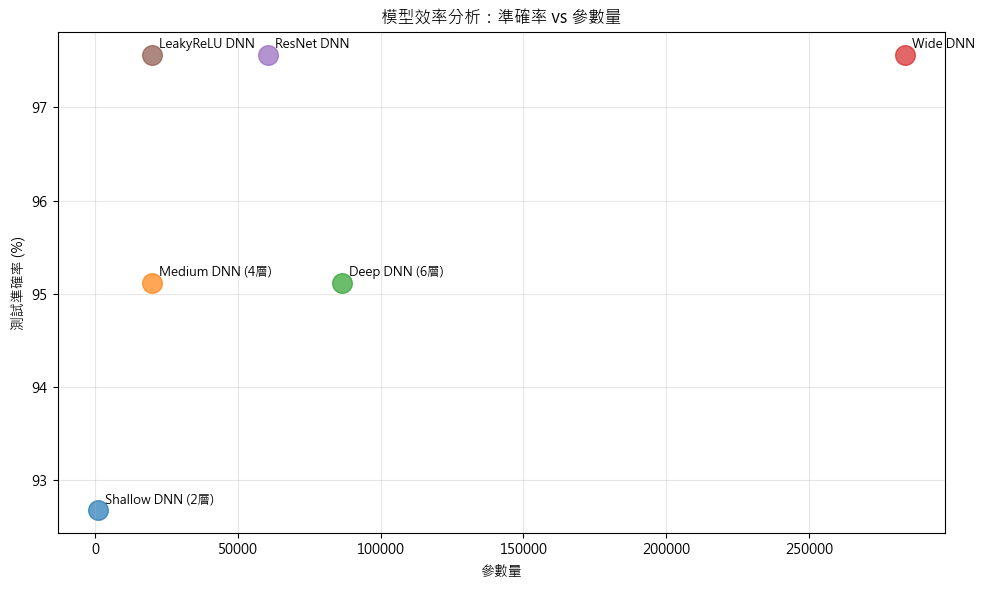

效率分析圖已儲存至 ./model/efficiency_analysis.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (name, data) in enumerate(results.items()):
    ax.scatter(data['params'], data['test_acc'] * 100, 
               s=200, label=name, alpha=0.7)
    ax.annotate(name, (data['params'], data['test_acc'] * 100),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

ax.set_xlabel('參數量')
ax.set_ylabel('測試準確率 (%)')
ax.set_title('模型效率分析：準確率 vs 參數量')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./model/efficiency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("效率分析圖已儲存至 ./model/efficiency_analysis.png")

## 10. 結論與建議

In [14]:
# 找出最佳模型
best_acc_model = max(results.keys(), key=lambda k: results[k]['test_acc'])
best_f1_model = max(results.keys(), key=lambda k: results[k]['test_f1'])
smallest_model = min(results.keys(), key=lambda k: results[k]['params'])
fastest_model = min(results.keys(), key=lambda k: results[k]['train_time'])

# 計算效率分數 (準確率 / 參數量)
efficiency = {k: results[k]['test_acc'] / results[k]['params'] * 10000 for k in results}
most_efficient = max(efficiency.keys(), key=lambda k: efficiency[k])

print("\n" + "=" * 70)
print("結論與建議")
print("=" * 70)
print(f"\n🏆 最高準確率: {best_acc_model}")
print(f"   測試準確率: {results[best_acc_model]['test_acc']*100:.2f}%")
print(f"   參數量: {results[best_acc_model]['params']:,}")

print(f"\n🎯 最高 F1 分數: {best_f1_model}")
print(f"   F1 分數: {results[best_f1_model]['test_f1']*100:.2f}%")

print(f"\n⚡ 最高效率 (準確率/參數量): {most_efficient}")
print(f"   效率分數: {efficiency[most_efficient]:.4f}")

print(f"\n📦 最小模型: {smallest_model}")
print(f"   參數量: {results[smallest_model]['params']:,}")
print(f"   準確率: {results[smallest_model]['test_acc']*100:.2f}%")

print(f"\n⏱️ 最快訓練: {fastest_model}")
print(f"   訓練時間: {results[fastest_model]['train_time']:.1f}s")

print("\n" + "-" * 70)
print("建議:")
print("-" * 70)
print(f"\n若追求最高準確率: 使用 {best_acc_model}")
print(f"若需要輕量化部署: 使用 {smallest_model}")
print(f"若追求性價比: 使用 {most_efficient}")
print("=" * 70)


結論與建議

🏆 最高準確率: Wide DNN
   測試準確率: 97.56%
   參數量: 283,588

🎯 最高 F1 分數: Wide DNN
   F1 分數: 97.53%

⚡ 最高效率 (準確率/參數量): Shallow DNN (2層)
   效率分數: 10.1182

📦 最小模型: Shallow DNN (2層)
   參數量: 916
   準確率: 92.68%

⏱️ 最快訓練: Medium DNN (4層)
   訓練時間: 0.5s

----------------------------------------------------------------------
建議:
----------------------------------------------------------------------

若追求最高準確率: 使用 Wide DNN
若需要輕量化部署: 使用 Shallow DNN (2層)
若追求性價比: 使用 Shallow DNN (2層)


In [15]:
# 儲存比較結果
results_df.to_csv('./model/model_comparison_results.csv', index=False, encoding='utf-8-sig')
print("\n結果已儲存至 ./model/model_comparison_results.csv")

# 顯示最終結果表格
print("\n最終比較結果:")
display(results_df)


結果已儲存至 ./model/model_comparison_results.csv

最終比較結果:


,模型,參數量,訓練時間(秒),訓練輪數,最佳驗證準確率,測試準確率(%),測試 F1 分數
4,ResNet DNN,60644,1.6,42,100.00,97.56,97.53
3,Wide DNN,283588,0.6,24,100.00,97.56,97.53
5,LeakyReLU DNN,19812,0.6,26,100.00,97.56,97.53
1,Medium DNN (4層),19812,0.5,23,97.44,95.12,95.12
2,Deep DNN (6層),86500,1.0,34,100.00,95.12,95.12
0,Shallow DNN (2層),916,1.0,33,97.44,92.68,92.73
